In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.models as models
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
trainTransform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

testTransform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

trainDir = "D:/SeniorProject/LLMImageLabels"
testDir = "D:/SeniorProject/CroppedImages"

trainDataset = ImageFolder(root=trainDir, transform=trainTransform)
testDataset = ImageFolder(root=testDir, transform=testTransform)
trainLoader = DataLoader(trainDataset, batch_size=32, shuffle=True)
testLoader = DataLoader(testDataset, batch_size=32, shuffle=True)

In [4]:
def evaluateModel(model, testLoader):
  
  model.eval()
  correct = 0
  total = 0
  # Testing predictions on test set generated earlier and returning the accuracy
  with torch.no_grad():
    for images, labels in testLoader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  accuracy = 100 * correct / total
  return accuracy

In [5]:
def trainModel(model, numEpochs):

    trainLosses = []
    trainAccuracies = []
    validLosses = []
    validAccuracies = []

    for epoch in range(numEpochs): 
        model.train()
        running_loss = 0.0
        correct = total = 0

        for i, data in enumerate(trainLoader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        trainLosses.append(running_loss / len(trainLoader))
        trainAccuracies.append(correct / total)

        model.eval()

        valLoss = 0
        correct = total = 0
        with torch.no_grad():
            for data in testLoader:
                images, labels = data
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                valLoss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        validLosses.append(valLoss / len(testLoader))
        validAccuracies.append(correct / total)
        print(f"Epoch {epoch + 1}/{numEpochs}, Train Loss: {trainLosses[-1]:.4f}, Train Accuracy: {trainAccuracies[-1]:.4f}, Validation Loss: {validLosses[-1]:.4f}, Validation Accuracy: {validAccuracies[-1]:.4f}")


    plt.plot(range(1, numEpochs + 1), trainLosses, label="Training Loss", color="blue")
    plt.plot(range(1, numEpochs + 1), validLosses, label="Validation Loss", color="orange")
    plt.plot(range(1, numEpochs + 1), validAccuracies, label="Validation Accuracy", color="green") # This is not working
    plt.xlabel("Epoch")
    plt.ylabel("Loss/Accuracy")
    plt.title("Statistics vs. Epochs")
    plt.legend()
    plt.show()
    
    return model

In [6]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5) 
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 53 * 53, 120)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 30)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [7]:
class BetterNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3) 
        self.conv2 = nn.Conv2d(16, 32, 3)
        self.conv3 = nn.Conv2d(32, 64, 3)

        self.bn1 = nn.BatchNorm2d(16)
        self.bn2 = nn.BatchNorm2d(32)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 26 * 26, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 30)
        self.fc4 = nn.Linear(30, 30)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

Epoch 1/10, Train Loss: 3.2731, Train Accuracy: 0.0866, Validation Loss: 3.4151, Validation Accuracy: 0.0671
Epoch 2/10, Train Loss: 2.7669, Train Accuracy: 0.2165, Validation Loss: 3.1159, Validation Accuracy: 0.1137
Epoch 3/10, Train Loss: 2.2797, Train Accuracy: 0.3450, Validation Loss: 3.1349, Validation Accuracy: 0.1506
Epoch 4/10, Train Loss: 1.7408, Train Accuracy: 0.5038, Validation Loss: 3.3347, Validation Accuracy: 0.1633
Epoch 5/10, Train Loss: 1.0051, Train Accuracy: 0.7178, Validation Loss: 3.9595, Validation Accuracy: 0.1652
Epoch 6/10, Train Loss: 0.4070, Train Accuracy: 0.8904, Validation Loss: 5.4769, Validation Accuracy: 0.1467
Epoch 7/10, Train Loss: 0.2370, Train Accuracy: 0.9360, Validation Loss: 5.9187, Validation Accuracy: 0.1506
Epoch 8/10, Train Loss: 0.0352, Train Accuracy: 0.9931, Validation Loss: 6.2372, Validation Accuracy: 0.1380
Epoch 9/10, Train Loss: 0.0082, Train Accuracy: 0.9990, Validation Loss: 6.8642, Validation Accuracy: 0.1526
Epoch 10/10, Train 

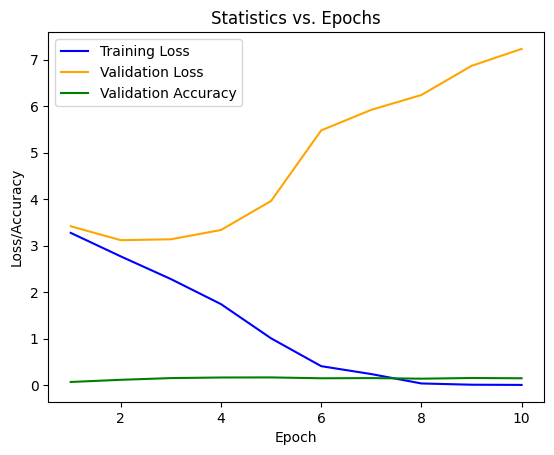

Accuracy: 14.67444120505345


In [27]:
model = Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
model = trainModel(model, 10)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy}")

Epoch 1/10, Train Loss: 2.6001, Train Accuracy: 0.2594, Validation Loss: 2.9467, Validation Accuracy: 0.1866
Epoch 2/10, Train Loss: 1.0362, Train Accuracy: 0.7131, Validation Loss: 4.1210, Validation Accuracy: 0.1817
Epoch 3/10, Train Loss: 0.1677, Train Accuracy: 0.9557, Validation Loss: 5.7770, Validation Accuracy: 0.1749
Epoch 4/10, Train Loss: 0.0441, Train Accuracy: 0.9900, Validation Loss: 6.9670, Validation Accuracy: 0.1837
Epoch 5/10, Train Loss: 0.0340, Train Accuracy: 0.9904, Validation Loss: 8.1412, Validation Accuracy: 0.1681
Epoch 6/10, Train Loss: 0.0863, Train Accuracy: 0.9756, Validation Loss: 7.9635, Validation Accuracy: 0.1497
Epoch 7/10, Train Loss: 0.0775, Train Accuracy: 0.9783, Validation Loss: 8.2480, Validation Accuracy: 0.1856
Epoch 8/10, Train Loss: 0.0278, Train Accuracy: 0.9929, Validation Loss: 9.8635, Validation Accuracy: 0.1633
Epoch 9/10, Train Loss: 0.0636, Train Accuracy: 0.9815, Validation Loss: 9.7398, Validation Accuracy: 0.1759
Epoch 10/10, Train 

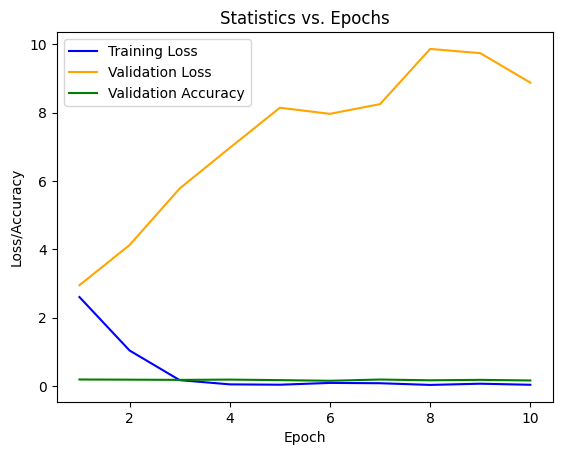

Accuracy: 15.840621963070943


In [21]:
model = Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 10)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy}")

Epoch 1/15, Train Loss: 3.2947, Train Accuracy: 0.0764, Validation Loss: 3.3105, Validation Accuracy: 0.0739
Epoch 2/15, Train Loss: 2.9699, Train Accuracy: 0.1526, Validation Loss: 3.0391, Validation Accuracy: 0.1672
Epoch 3/15, Train Loss: 2.5881, Train Accuracy: 0.2364, Validation Loss: 2.7835, Validation Accuracy: 0.1846
Epoch 4/15, Train Loss: 2.3216, Train Accuracy: 0.2989, Validation Loss: 2.6612, Validation Accuracy: 0.2196
Epoch 5/15, Train Loss: 2.1565, Train Accuracy: 0.3478, Validation Loss: 2.6532, Validation Accuracy: 0.2264
Epoch 6/15, Train Loss: 1.9321, Train Accuracy: 0.4074, Validation Loss: 2.4743, Validation Accuracy: 0.2527
Epoch 7/15, Train Loss: 1.7113, Train Accuracy: 0.4709, Validation Loss: 2.3973, Validation Accuracy: 0.2595
Epoch 8/15, Train Loss: 1.5082, Train Accuracy: 0.5335, Validation Loss: 3.0984, Validation Accuracy: 0.2021
Epoch 9/15, Train Loss: 1.4825, Train Accuracy: 0.5522, Validation Loss: 2.3894, Validation Accuracy: 0.2867
Epoch 10/15, Train 

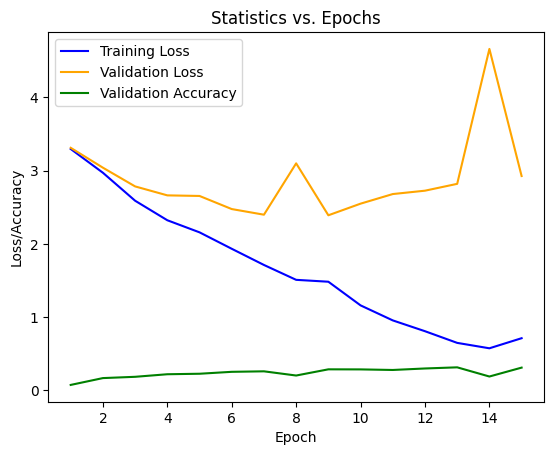

Accuracy: 31.000971817298346


In [43]:
model = BetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
model = trainModel(model, 15)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy}")

Epoch 1/20, Train Loss: 3.2114, Train Accuracy: 0.0999, Validation Loss: 3.1816, Validation Accuracy: 0.1030
Epoch 2/20, Train Loss: 2.7200, Train Accuracy: 0.1979, Validation Loss: 2.8863, Validation Accuracy: 0.1642
Epoch 3/20, Train Loss: 2.4562, Train Accuracy: 0.2572, Validation Loss: 2.7115, Validation Accuracy: 0.1914
Epoch 4/20, Train Loss: 2.2501, Train Accuracy: 0.3145, Validation Loss: 2.5796, Validation Accuracy: 0.2089
Epoch 5/20, Train Loss: 2.0608, Train Accuracy: 0.3631, Validation Loss: 2.5688, Validation Accuracy: 0.2187
Epoch 6/20, Train Loss: 1.8395, Train Accuracy: 0.4266, Validation Loss: 2.5328, Validation Accuracy: 0.2235
Epoch 7/20, Train Loss: 1.6371, Train Accuracy: 0.4870, Validation Loss: 2.4498, Validation Accuracy: 0.2478
Epoch 8/20, Train Loss: 1.4446, Train Accuracy: 0.5395, Validation Loss: 2.4721, Validation Accuracy: 0.2653
Epoch 9/20, Train Loss: 1.2433, Train Accuracy: 0.6005, Validation Loss: 2.6775, Validation Accuracy: 0.2585
Epoch 10/20, Train 

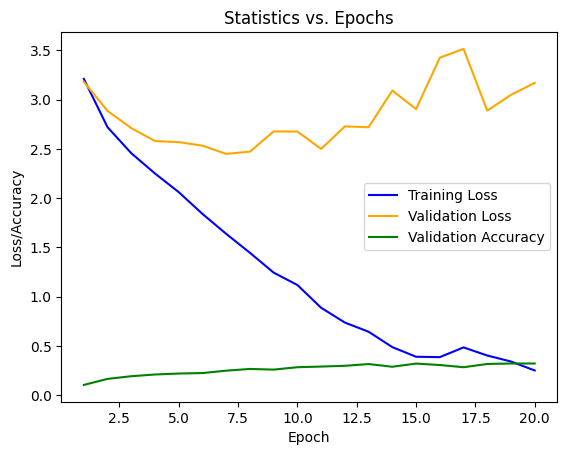

Accuracy: 32.06997084548105


In [44]:
model = BetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
model = trainModel(model, 20)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy}")

Epoch 1/60, Train Loss: 3.3713, Train Accuracy: 0.0630, Validation Loss: 3.3959, Validation Accuracy: 0.0709
Epoch 2/60, Train Loss: 3.1168, Train Accuracy: 0.0980, Validation Loss: 3.1187, Validation Accuracy: 0.0884
Epoch 3/60, Train Loss: 2.8991, Train Accuracy: 0.1212, Validation Loss: 2.9831, Validation Accuracy: 0.1069
Epoch 4/60, Train Loss: 2.7622, Train Accuracy: 0.1568, Validation Loss: 2.9606, Validation Accuracy: 0.1186
Epoch 5/60, Train Loss: 2.6159, Train Accuracy: 0.2037, Validation Loss: 2.8259, Validation Accuracy: 0.1827
Epoch 6/60, Train Loss: 2.4967, Train Accuracy: 0.2389, Validation Loss: 2.8011, Validation Accuracy: 0.1905
Epoch 7/60, Train Loss: 2.3377, Train Accuracy: 0.2724, Validation Loss: 2.7690, Validation Accuracy: 0.2080
Epoch 8/60, Train Loss: 2.2004, Train Accuracy: 0.2941, Validation Loss: 2.6931, Validation Accuracy: 0.2332
Epoch 9/60, Train Loss: 2.0799, Train Accuracy: 0.3219, Validation Loss: 2.9305, Validation Accuracy: 0.2352
Epoch 10/60, Train 

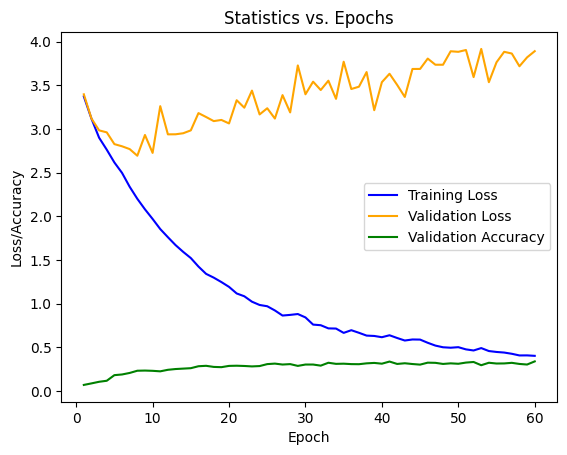

Accuracy: 34.01360544217687


In [52]:
model = BetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 60)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy}")

Epoch 1/20, Train Loss: 3.3554, Train Accuracy: 0.0585, Validation Loss: 3.3655, Validation Accuracy: 0.0651
Epoch 2/20, Train Loss: 3.1732, Train Accuracy: 0.0980, Validation Loss: 3.1969, Validation Accuracy: 0.1108
Epoch 3/20, Train Loss: 3.0417, Train Accuracy: 0.1271, Validation Loss: 3.1005, Validation Accuracy: 0.1166
Epoch 4/20, Train Loss: 2.9197, Train Accuracy: 0.1514, Validation Loss: 2.9931, Validation Accuracy: 0.1234
Epoch 5/20, Train Loss: 2.8132, Train Accuracy: 0.1785, Validation Loss: 2.9137, Validation Accuracy: 0.1535
Epoch 6/20, Train Loss: 2.7052, Train Accuracy: 0.2054, Validation Loss: 2.9370, Validation Accuracy: 0.1409
Epoch 7/20, Train Loss: 2.6331, Train Accuracy: 0.2192, Validation Loss: 2.8395, Validation Accuracy: 0.1701
Epoch 8/20, Train Loss: 2.5359, Train Accuracy: 0.2458, Validation Loss: 2.7703, Validation Accuracy: 0.1681
Epoch 9/20, Train Loss: 2.4985, Train Accuracy: 0.2675, Validation Loss: 2.7991, Validation Accuracy: 0.1613
Epoch 10/20, Train 

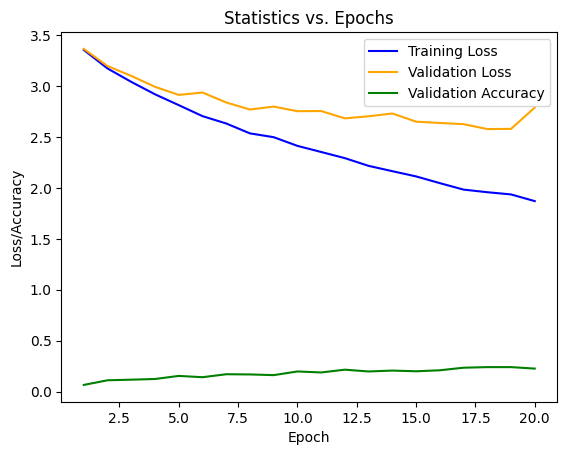

Accuracy: 22.546161321671526


In [59]:
model = BetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
model = trainModel(model, 20)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy}")

In [13]:
model = BetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 50)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy}")

Epoch 1/50, Train Loss: 4.0141, Train Accuracy: 0.0515, Validation Loss: 3.4559, Validation Accuracy: 0.0330
Epoch 2/50, Train Loss: 3.3567, Train Accuracy: 0.0526, Validation Loss: 3.4680, Validation Accuracy: 0.0330
Epoch 3/50, Train Loss: 3.3560, Train Accuracy: 0.0548, Validation Loss: 3.4747, Validation Accuracy: 0.0330
Epoch 4/50, Train Loss: 3.3556, Train Accuracy: 0.0548, Validation Loss: 3.4795, Validation Accuracy: 0.0330
Epoch 5/50, Train Loss: 3.3610, Train Accuracy: 0.0547, Validation Loss: 3.4664, Validation Accuracy: 0.0330
Epoch 6/50, Train Loss: 3.3571, Train Accuracy: 0.0538, Validation Loss: 3.4717, Validation Accuracy: 0.0330
Epoch 7/50, Train Loss: 3.3565, Train Accuracy: 0.0544, Validation Loss: 3.4692, Validation Accuracy: 0.0330
Epoch 8/50, Train Loss: 3.3569, Train Accuracy: 0.0548, Validation Loss: 3.4705, Validation Accuracy: 0.0330
Epoch 9/50, Train Loss: 3.3563, Train Accuracy: 0.0529, Validation Loss: 3.4682, Validation Accuracy: 0.0330


KeyboardInterrupt: 

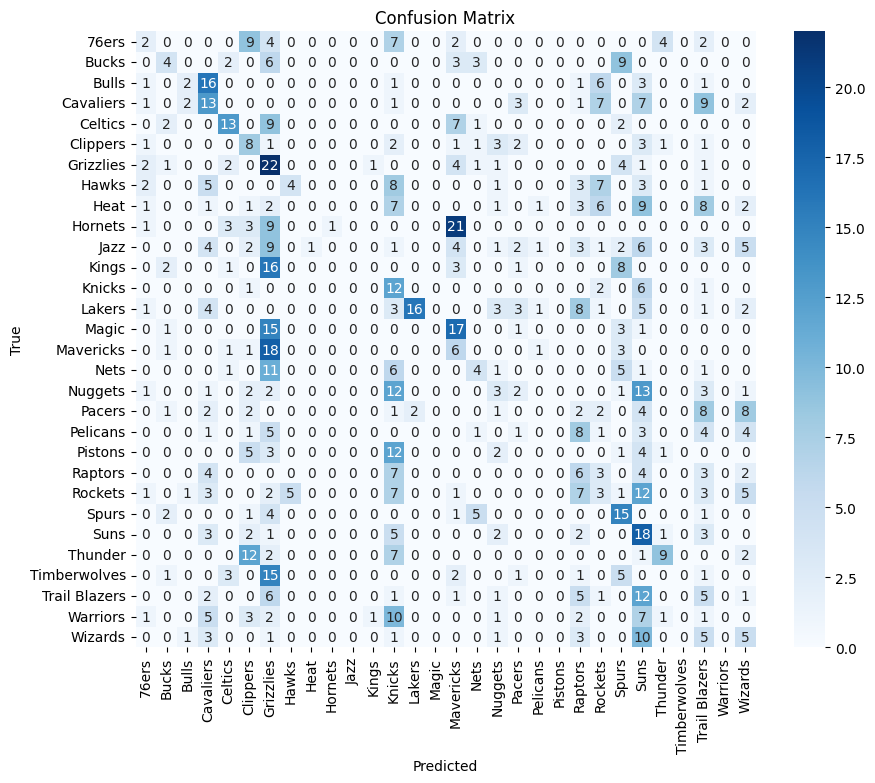

In [ ]:
modelPrediction = []
realLabels = []
classNames = trainDataset.classes

with torch.no_grad():
    for inputs, labels in testLoader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        modelPrediction.extend(preds.cpu().numpy())
        realLabels.extend(labels.cpu().numpy())

cm = confusion_matrix(realLabels, modelPrediction)
labels_unique = sorted(set(classNames))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_unique, yticklabels=labels_unique)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [42]:
import numpy as np

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Number of classes
num_classes = len(classNames)

print("Per-class accuracy:\n")
for i in range(num_classes):
    # Get indices where the true label == i
    idx = all_labels == i
    # Compute accuracy for class i
    correct = np.sum(all_preds[idx] == all_labels[idx])
    total = np.sum(idx)
    acc = 100.0 * correct / total if total > 0 else 0.0
    print(f"{classNames[i]}: {acc:.2f}% ({correct}/{total})")


Per-class accuracy:

76ers: 43.33% (13/30)
Bucks: 29.63% (8/27)
Bulls: 19.35% (6/31)
Cavaliers: 23.91% (11/46)
Celtics: 76.47% (26/34)
Clippers: 16.67% (4/24)
Grizzlies: 35.00% (14/40)
Hawks: 20.59% (7/34)
Heat: 7.14% (3/42)
Hornets: 73.68% (28/38)
Jazz: 26.67% (12/45)
Kings: 22.58% (7/31)
Knicks: 45.45% (10/22)
Lakers: 75.00% (36/48)
Magic: 2.63% (1/38)
Mavericks: 6.45% (2/31)
Nets: 3.33% (1/30)
Nuggets: 12.20% (5/41)
Pacers: 39.39% (13/33)
Pelicans: 0.00% (0/29)
Pistons: 35.71% (10/28)
Raptors: 17.24% (5/29)
Rockets: 31.37% (16/51)
Spurs: 48.28% (14/29)
Suns: 43.24% (16/37)
Thunder: 39.39% (13/33)
Timberwolves: 20.69% (6/29)
Trail Blazers: 14.29% (5/35)
Warriors: 2.94% (1/34)
Wizards: 33.33% (10/30)


In [39]:
class LeNet5(nn.Module):
        def __init__(self, num_classes):
            super(LeNet5, self).__init__()
            self.layer1 = nn.Sequential(
                nn.Conv2d(3, 6, kernel_size=5, stride=1, padding=0),
                nn.BatchNorm2d(6),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = 2, stride = 2))
            self.layer2 = nn.Sequential(
                nn.Conv2d(6, 16, kernel_size=5, stride=3, padding=0),
                nn.BatchNorm2d(16),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = 2, stride = 2))
            self.fc = nn.Linear(16 * 18 * 18, 120)
            self.relu = nn.ReLU()
            self.fc1 = nn.Linear(120, 84)
            self.relu1 = nn.ReLU()
            self.fc2 = nn.Linear(84, num_classes)
            
        def forward(self, x):
            out = self.layer1(x)
            out = self.layer2(out)
            out = out.reshape(out.size(0), -1)
            out = self.fc(out)
            out = self.relu(out)
            out = self.fc1(out)
            out = self.relu1(out)
            out = self.fc2(out)
            return out

Epoch 1/20, Train Loss: 2.7777, Train Accuracy: 0.2071, Validation Loss: 2.9124, Validation Accuracy: 0.1467
Epoch 2/20, Train Loss: 2.2514, Train Accuracy: 0.3384, Validation Loss: 2.8046, Validation Accuracy: 0.1701
Epoch 3/20, Train Loss: 1.9047, Train Accuracy: 0.4344, Validation Loss: 2.7026, Validation Accuracy: 0.2138
Epoch 4/20, Train Loss: 1.6093, Train Accuracy: 0.5220, Validation Loss: 2.9495, Validation Accuracy: 0.1856
Epoch 5/20, Train Loss: 1.3365, Train Accuracy: 0.6039, Validation Loss: 2.8869, Validation Accuracy: 0.1953
Epoch 6/20, Train Loss: 1.0671, Train Accuracy: 0.6858, Validation Loss: 3.2022, Validation Accuracy: 0.1992
Epoch 7/20, Train Loss: 0.8307, Train Accuracy: 0.7514, Validation Loss: 3.1226, Validation Accuracy: 0.2284
Epoch 8/20, Train Loss: 0.6283, Train Accuracy: 0.8091, Validation Loss: 3.4430, Validation Accuracy: 0.2070
Epoch 9/20, Train Loss: 0.4302, Train Accuracy: 0.8730, Validation Loss: 3.6304, Validation Accuracy: 0.2099
Epoch 10/20, Train 

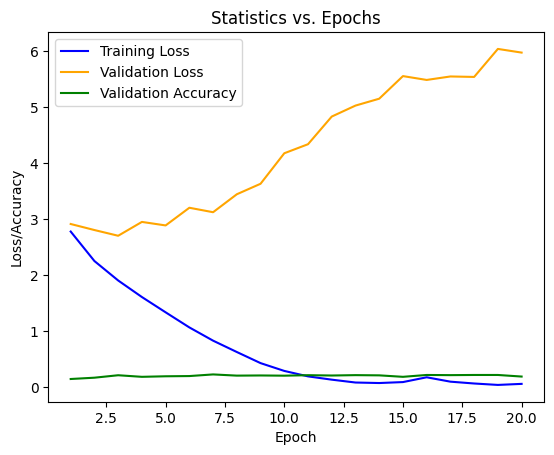

Accuracy: 19.0476%


In [41]:
model = LeNet5(30).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 20)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")

Epoch 1/30, Train Loss: 2.7207, Train Accuracy: 0.2062, Validation Loss: 2.8980, Validation Accuracy: 0.1652
Epoch 2/30, Train Loss: 2.2318, Train Accuracy: 0.3345, Validation Loss: 2.6558, Validation Accuracy: 0.2089
Epoch 3/30, Train Loss: 1.9494, Train Accuracy: 0.4188, Validation Loss: 2.5324, Validation Accuracy: 0.2507
Epoch 4/30, Train Loss: 1.7055, Train Accuracy: 0.4838, Validation Loss: 2.2627, Validation Accuracy: 0.3372
Epoch 5/30, Train Loss: 1.5066, Train Accuracy: 0.5385, Validation Loss: 2.5679, Validation Accuracy: 0.2886
Epoch 6/30, Train Loss: 1.3271, Train Accuracy: 0.6006, Validation Loss: 2.1110, Validation Accuracy: 0.3907
Epoch 7/30, Train Loss: 1.1408, Train Accuracy: 0.6577, Validation Loss: 2.1799, Validation Accuracy: 0.4101
Epoch 8/30, Train Loss: 0.9963, Train Accuracy: 0.7034, Validation Loss: 1.9842, Validation Accuracy: 0.4791
Epoch 9/30, Train Loss: 0.8538, Train Accuracy: 0.7427, Validation Loss: 1.7666, Validation Accuracy: 0.5102
Epoch 10/30, Train 

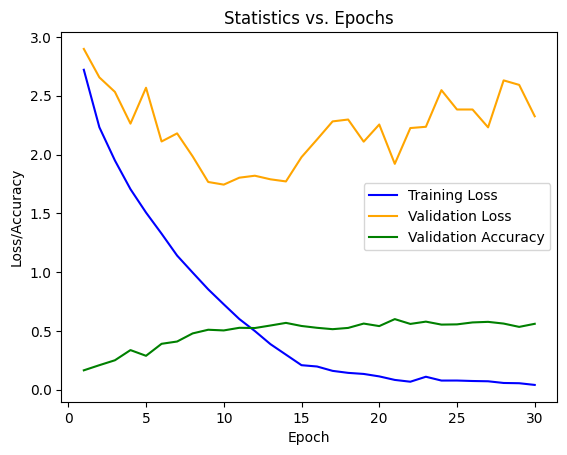

Accuracy: 56.0739%


In [44]:
model = models.resnet18()
model.fc = nn.Linear(512, 30)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = trainModel(model, 30)
print(f"Accuracy: {evaluateModel(model, testLoader):.4f}%")